In [1]:
# This code aim to perform a bootstrap to municipality level timeseries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [69]:
df = pd.read_parquet('/opt/storage/shared/aesop/aesop_shared/ensamble_modelling/aesop_02_02_2026_with_MEM.parquet')


In [70]:
df.columns

Index(['co_uf', 'nm_uf', 'nm_municipio', 'co_ibge', 'epiyear', 'epiweek',
       'year_week', 'atend_totais', 'atend_ivas', 'mem_surge', 'mem_surge_01',
       'mem_surge_01_without_isolated', 'mem_surge_01_corect_with_consec',
       'warning_final_mem_surge_01'],
      dtype='object')

# Aqui começa o codigo

In [71]:
def insert_outbreak(series, start_week, duration, k, lognorm_mean=0, lognorm_sd=0.5, rng=None):

    if rng is None:
        rng = np.random.default_rng()

    series = series.copy()
    n = len(series)

    sigma = np.std(series)

    # total outbreak size
    outbreak_size = rng.poisson(k * sigma)

    if outbreak_size == 0:
        return series, {"start": start_week, "end": start_week, "size": 0}

    # lognormal temporal distribution
    times = rng.lognormal(lognorm_mean, lognorm_sd, outbreak_size)

    # scale to chosen duration
    offsets = np.floor((times / times.max()) * (duration-1)).astype(int)

    outbreak_weeks = start_week + offsets
    outbreak_weeks = outbreak_weeks[outbreak_weeks < n]

    for w in outbreak_weeks:
        series[w] += 1

    return series, {
        "start": start_week,
        "end": int(start_week + duration),
        "size": int(outbreak_size),
        'k':k,
        "duration": duration
    }

In [72]:
def generate_replicate(series, max_outbreaks=2, min_gap=4, rng=None):

    if rng is None:
        rng = np.random.default_rng()

    n = len(series)
    new_series = series.copy()

    # number of outbreaks
    K = rng.integers(1, max_outbreaks + 1)

    outbreaks = []

    attempts = 0
    max_attempts = 200

    while len(outbreaks) < K and attempts < max_attempts:

        start = rng.integers(415, n-10) # aqui muda as o inicio da semana
        duration = rng.integers(4, 11)
        end = start + duration

        valid = True

        # check overlap + minimum gap
        for ob in outbreaks:

            existing_start = ob["start"]
            existing_end = ob["end"]

            if not (end + min_gap < existing_start or start > existing_end + min_gap):
                valid = False
                break

        if valid:

            k = rng.uniform(2, 10)

            new_series, info = insert_outbreak(
                new_series,
                start_week=start,
                duration=duration,
                k=k,
                rng=rng
            )

            outbreaks.append(info)

        attempts += 1

    return new_series, outbreaks

In [73]:
set_muni = df[df.co_ibge == 110001 ][['co_ibge','year_week', 'atend_ivas', 'warning_final_mem_surge_01']]
#set_muni = set_muni[(set_muni.year_week >= '2022-42') & (set_muni.year_week <= '2025-32')]
set_muni = set_muni[set_muni.year_week <= '2025-32']

# Precisa adaptar o codigo da proxima celula pra rodar para todos os municipios

In [74]:
replicates = []
outbreak_metadata = []

baseline = set_muni["atend_ivas"].values

rng = np.random.default_rng(42)

for r in range(32): # numero de replicas

    new_series, outbreaks = generate_replicate(baseline, rng=rng)

    replicates.append(new_series)
    outbreak_metadata.append(outbreaks)

#  formatar o dado de saida co_ibge 	year_week 	epidemi_cal_start 	atend_ivas + as colunas das replicas

In [75]:
replicates_df = pd.DataFrame(replicates).T
replicates_df.columns = [f"replicate_{i}" for i in range(len(replicates))]

In [76]:
set_muni = set_muni.assign(replicate_3 = replicates_df.replicate_3)

# precisa formatar tb a saida do outbreak_metadata , separado do dado anterior. 
         * precisa adicionar o codigo ibge
         * transformas start e end para o formato de semana epidemiologica
         * ver qual o melhor formato para salvar este dado
            colunas: co_ibge, replica (0, 1, ...), year_week 	epidemi_cal_start 	atend_ivas, 'replicate_0', 'replicate_1', 'replicate_2', 'replicate_3',
       'replicate_4', 'replicate_5', 'replicate_6', 'replicate_7',
       'replicate_8', 'replicate_9', 'replicate_10', 'replicate_11',
       'replicate_12', 'replicate_13', 'replicate_14', 'replicate_15',
       'replicate_16', 'replicate_17', 'replicate_18', 'replicate_19',
       'replicate_20', 'replicate_21', 'replicate_22', 'replicate_23',
       'replicate_24', 'replicate_25', 'replicate_26', 'replicate_27',
       'replicate_28', 'replicate_29', 'replicate_30', 'replicate_31'

# pode apagar daqui pra baixo

In [80]:
outbreak_metadata

[[{'start': 433,
   'end': 441,
   'size': 521,
   'k': 8.86878335929106,
   'duration': 8}],
 [{'start': 422,
   'end': 426,
   'size': 456,
   'k': 8.042641382357957,
   'duration': 4}],
 [{'start': 425,
   'end': 431,
   'size': 468,
   'k': 7.99694895138294,
   'duration': 6},
  {'start': 436,
   'end': 443,
   'size': 484,
   'k': 7.3748335089125385,
   'duration': 7}],
 [{'start': 435,
   'end': 441,
   'size': 146,
   'k': 2.569955818932729,
   'duration': 6},
  {'start': 416,
   'end': 426,
   'size': 138,
   'k': 2.7547320211172437,
   'duration': 10}],
 [{'start': 431,
   'end': 439,
   'size': 246,
   'k': 4.461027883393043,
   'duration': 8}],
 [{'start': 429,
   'end': 435,
   'size': 251,
   'k': 4.351683767396568,
   'duration': 6},
  {'start': 415,
   'end': 419,
   'size': 530,
   'k': 8.985919490831048,
   'duration': 4}],
 [{'start': 431,
   'end': 436,
   'size': 253,
   'k': 4.544513176869436,
   'duration': 5},
  {'start': 419,
   'end': 424,
   'size': 568,
   'k

In [79]:
set_muni

,co_ibge,year_week,atend_ivas,warning_final_mem_surge_01,replicate_3
414,110001,2024-50,20,0,20
415,110001,2024-51,26,0,26
416,110001,2024-52,5,0,9
417,110001,2025-01,11,0,61
418,110001,2025-02,47,0,103
419,110001,2025-03,48,0,61
420,110001,2025-04,27,0,34
421,110001,2025-05,28,0,29
422,110001,2025-06,22,0,26
423,110001,2025-07,10,0,11


In [78]:
replicates_df

,replicate_0,replicate_1,replicate_2,replicate_3,replicate_4,replicate_5,replicate_6,replicate_7,replicate_8,replicate_9,...,replicate_22,replicate_23,replicate_24,replicate_25,replicate_26,replicate_27,replicate_28,replicate_29,replicate_30,replicate_31
0,9,9,9,9,9,9,9,9,9,9,...,9,9,9,9,9,9,9,9,9,9
1,16,16,16,16,16,16,16,16,16,16,...,16,16,16,16,16,16,16,16,16,16
2,15,15,15,15,15,15,15,15,15,15,...,15,15,15,15,15,15,15,15,15,15
3,17,17,17,17,17,17,17,17,17,17,...,17,17,17,17,17,17,17,17,17,17
4,11,11,11,11,11,11,11,11,11,11,...,11,11,11,11,11,11,11,11,11,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
444,35,35,35,35,35,35,35,35,35,35,...,35,36,35,35,35,35,35,36,35,35
445,22,22,22,22,22,22,22,22,22,22,...,22,22,22,22,22,22,22,22,22,22
446,25,25,25,25,25,25,25,25,25,25,...,25,25,25,25,25,25,25,25,25,25
447,18,18,18,18,18,18,18,18,18,18,...,18,18,18,18,18,18,18,18,18,18


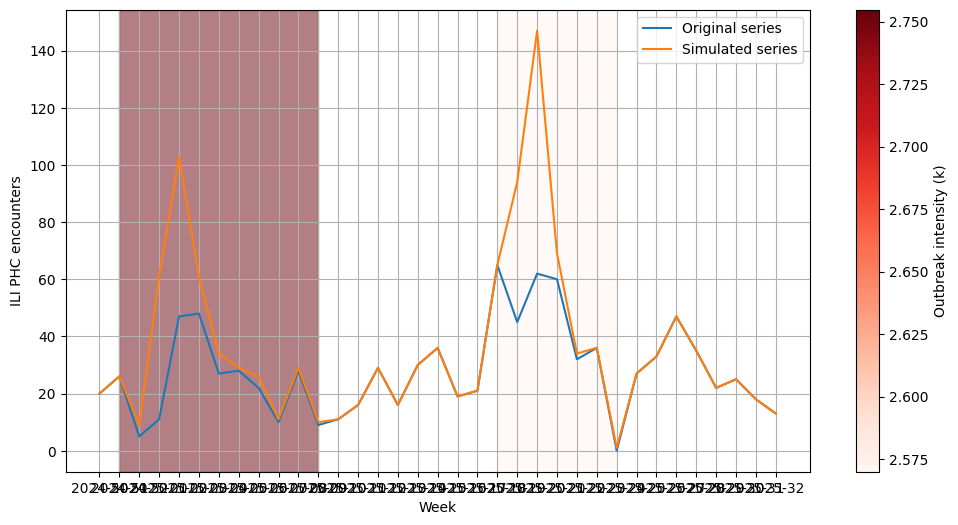

In [77]:

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib as mpl # Added for the new colormap syntax

rep = 3

set_muni = set_muni[set_muni.year_week >= '2024-50']

plt.figure(figsize=(12, 6))

# Plot original and simulated series
plt.plot(set_muni["year_week"],
         set_muni["atend_ivas"],
         label="Original series")

plt.plot(set_muni["year_week"],
         set_muni.replicate_3,
         #replicates_df[418:][f"replicate_{rep}"],
         label="Simulated series")

# Extract intensity values
k_values = [ob["k"] for ob in outbreak_metadata[rep]]

# Normalize intensity for color mapping
# (Added a fallback [0, 1] if k_values is empty to prevent errors)
vmin = min(k_values) if k_values else 0
vmax = max(k_values) if k_values else 1
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

# --- FIX 1: Modern Colormap Syntax ---
cmap = mpl.colormaps["Reds"]

# Plot outbreaks
for outbreak in outbreak_metadata[rep]:
    start = outbreak["start"]
    end = outbreak["end"]
    k = outbreak["k"]

    color = cmap(norm(k))

    plt.axvspan(set_muni["year_week"][start -1], #.iloc,
                set_muni["year_week"][end -1],
                color=color,
                alpha=0.5)

# Colorbar legend
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

# --- FIX 2: Explicitly pass the Axes to the colorbar ---
cbar = plt.colorbar(sm, ax=plt.gca())
cbar.set_label("Outbreak intensity (k)")

plt.xlabel("Week")
plt.ylabel("ILI PHC encounters")

plt.legend()
plt.grid(True)

plt.show()

In [47]:
set_muni = set_muni[set_muni.year_week >= '2025-01']

In [48]:
len(set_muni)

32